In [2]:
#General imports
resol = 300
import matplotlib.pyplot as plt
from matplotlib.ticker import LogLocator, NullFormatter
import pandas as pd

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "axes.linewidth": 0.7,
    "xtick.major.width": 0.6,
    "ytick.major.width": 0.6,
})

import sys
import numpy as np
from pathlib import Path
pi = np.pi

project_root = Path().resolve().parents[0]
sys.path.append(str(project_root))

#Local imports
from experiments.coincidence_vs_n import run_coincidence_vs_n
from src.coincidence_theory import get_C

<h1> Run the experiment </h1>

In [3]:
#Physical parameters
omega_A = 10*pi
Gamma = 5*pi

#Order of the bare parameters
n_tab = [-1,0,1,2,3,4,5]

#Different photon frequencies
omega_q_tab = [9.5*pi, 9*pi, 8.5*pi]
delta_q = 0.05*pi


#Prepare frequency windows
omega_ref = 0*pi
bandwidth_tab = [12*pi, 13*pi, 14*pi, 15*pi]

frequency_windows = [(omega_ref - bandwidth_tab[0], omega_ref + bandwidth_tab[0]),
                     (omega_ref - bandwidth_tab[1], omega_ref + bandwidth_tab[1]),
                     (omega_ref - bandwidth_tab[2], omega_ref + bandwidth_tab[2]),
                     (omega_ref - bandwidth_tab[3], omega_ref + bandwidth_tab[3])]

Run the experiment

In [4]:
index_omega_q_to_run = [2]
xp_to_run = [1,2,3,4]

for index_omega_q in index_omega_q_to_run:
        for index_experiment in xp_to_run:
                print(f"Running index omega q {index_omega_q} for frequency window {index_experiment}")

                omega_q = omega_q_tab[index_omega_q-1]

                cutoffs = {'ir_cutoff': frequency_windows[index_experiment-1][0], 'uv_cutoff': frequency_windows[index_experiment-1][1]}
                
                #Parameters of the simulation
                L = 50

                param_cavity_physical = {'omega_A': omega_A, 'Gamma': Gamma, 'L': L}

                param_time_evol = {'T': L/2, 'dt': 0.01}

                param_photons = {'omega_p': [omega_q, omega_q], 
                                'delta_k': [delta_q, delta_q],
                                'x_0': [-L/4, -L/4]}
                        
                _, coincidence_tab = run_coincidence_vs_n(param_photons, param_cavity_physical, param_time_evol, cutoffs, n_tab,
                                                          index_omega_q=index_omega_q, index_experiment=index_experiment)
                
                print("------------- \n")

Running index omega q 2 for frequency window 1


100%|██████████| 7/7 [16:56<00:00, 145.15s/it]


------------- 

Running index omega q 2 for frequency window 2


100%|██████████| 7/7 [25:30<00:00, 218.61s/it]


------------- 

Running index omega q 2 for frequency window 3


100%|██████████| 7/7 [27:53<00:00, 239.03s/it]


------------- 

Running index omega q 2 for frequency window 4


100%|██████████| 7/7 [31:48<00:00, 272.62s/it]

------------- 



<h1> Results on single frequency </h1>

Load the data

In [5]:
index_omega_q = 2
xp_to_plot = [1,2,3,4]

theoretical_val = get_C(omega_A, Gamma, omega_q_tab[index_omega_q-1])
error_to_plot = []

for index_experiment in xp_to_plot:
    data_file = f"../results/csv_files/coincidence_vs_n/coincidence_vs_n_omega{index_omega_q}_xp{index_experiment}.csv"
    df = pd.read_csv(data_file)
    coincidence_tab = df['coincidence_tab'].to_numpy()

    error_to_plot.append(np.abs(coincidence_tab - theoretical_val) / theoretical_val)

Create the figure

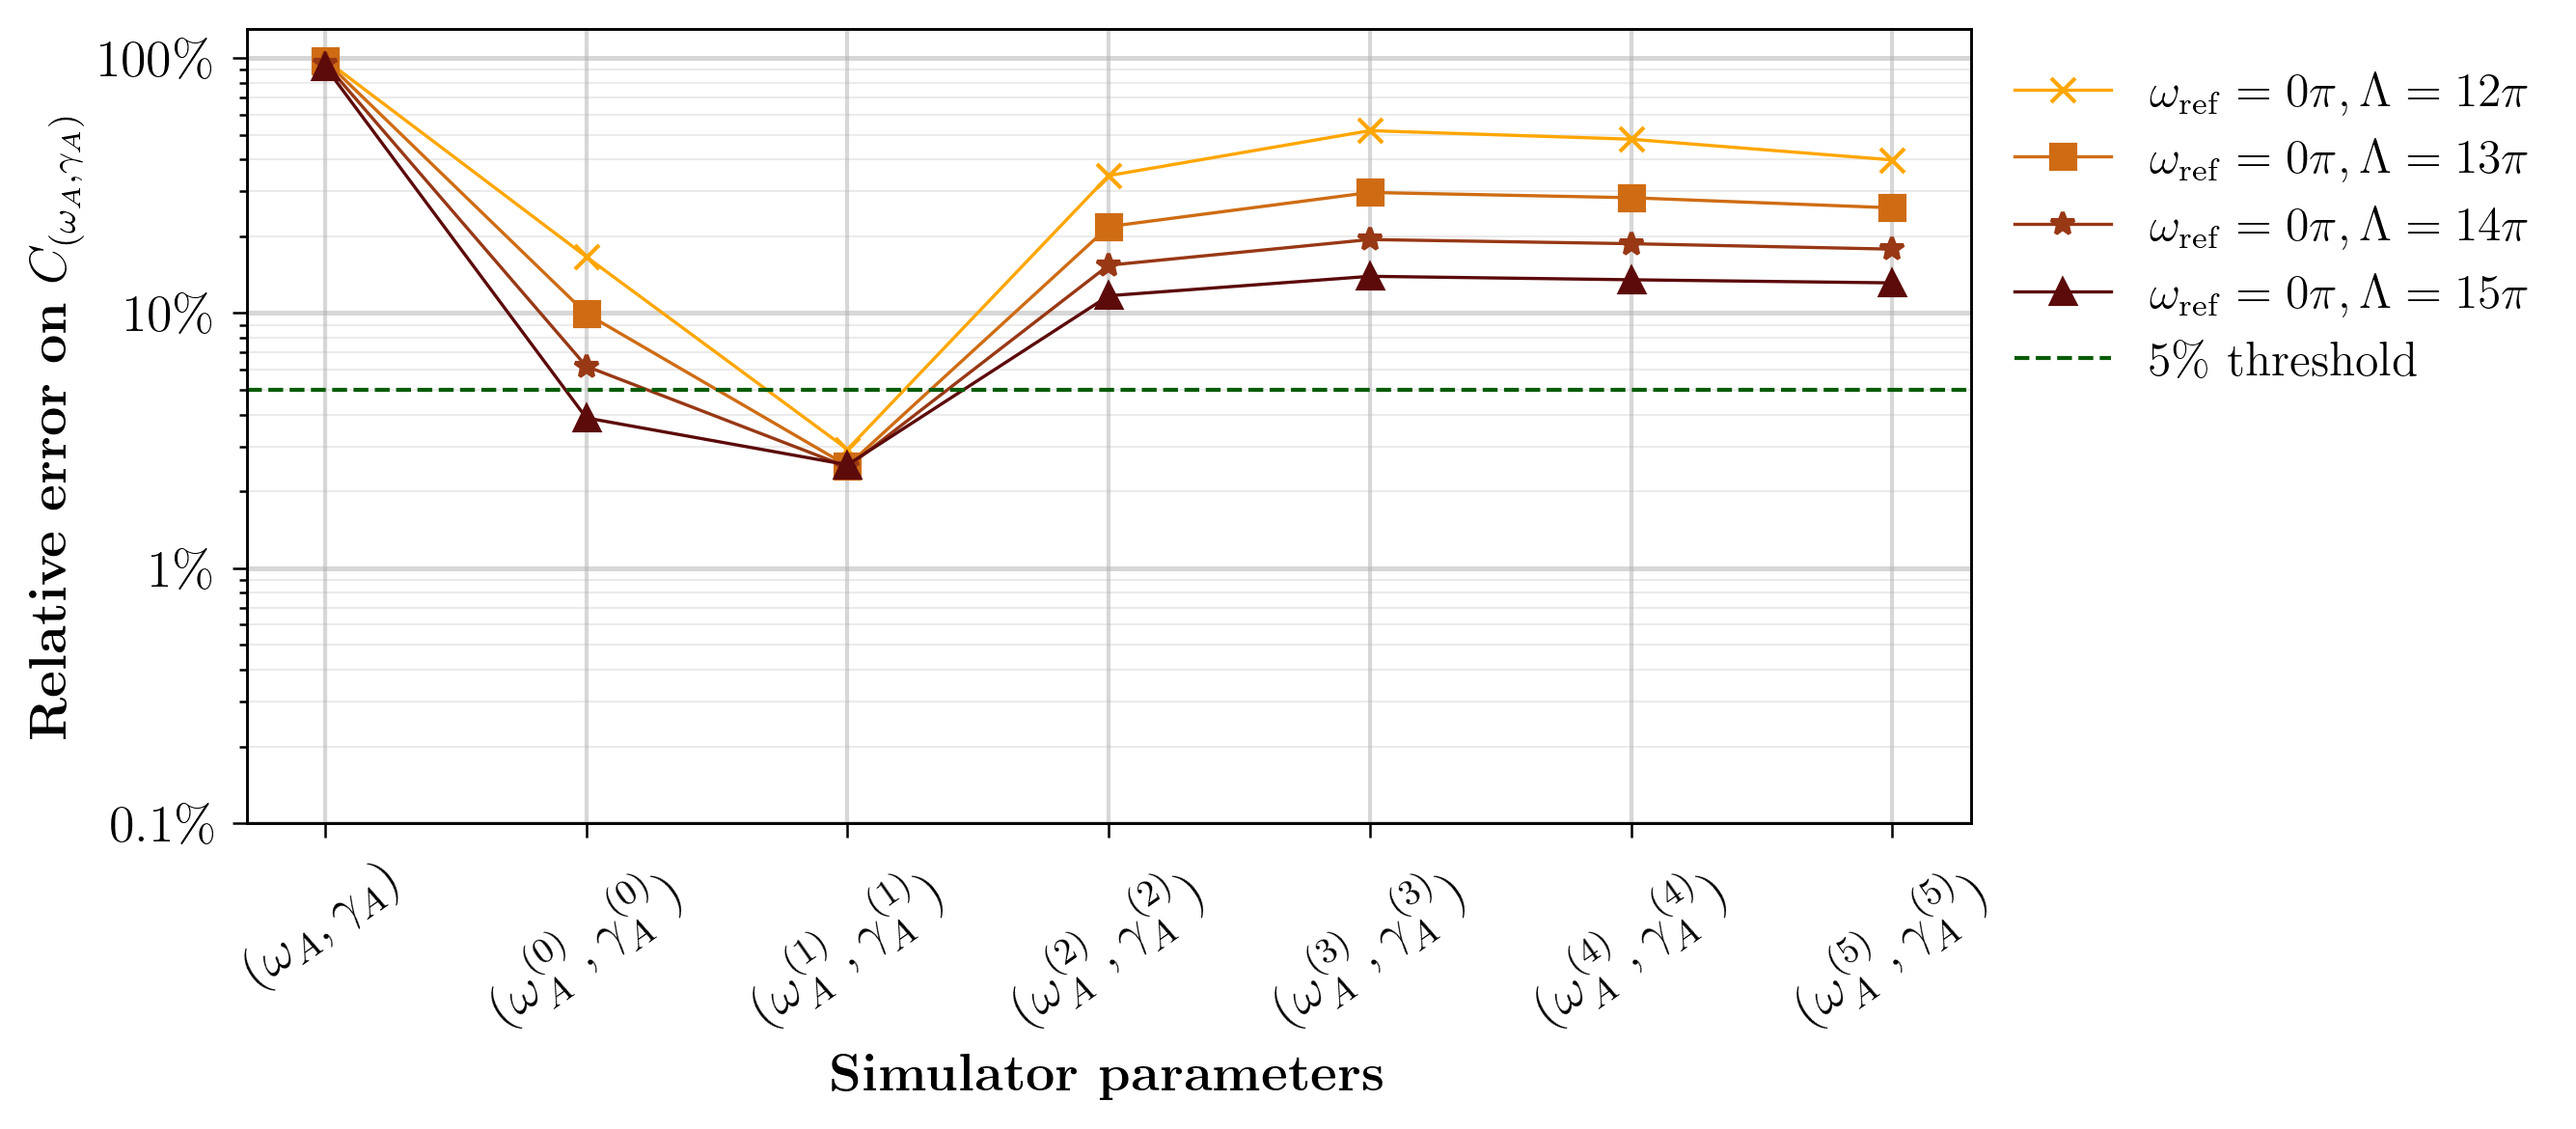

In [9]:
# plot
fig, ax = plt.subplots(figsize=(9, 4), dpi=300)

# labels correspondant aux 4 courbes
labels = [
    r'$\omega_{\rm ref} = 0 \pi, \Lambda = 12 \pi$',
    r'$\omega_{\rm ref} = 0 \pi, \Lambda = 13 \pi$',
    r'$\omega_{\rm ref} = 0 \pi, \Lambda = 14 \pi$',
    r'$\omega_{\rm ref} = 0 \pi, \Lambda = 15 \pi$'
]

markers = ['x','s','*','^']
colors = ['#ffa600', '#cf6c13', '#983815', '#5c0a0a']


# positions x (5 points sur la figure)
x_labels = [
    r'$(\omega_A,\gamma_A)$',
    r'$(\omega_A^{(0)},\gamma_A^{(0)})$',
    r'$(\omega_A^{(1)},\gamma_A^{(1)})$',
    r'$(\omega_A^{(2)},\gamma_A^{(2)})$',
    r'$(\omega_A^{(3)},\gamma_A^{(3)})$',
    r'$(\omega_A^{(4)},\gamma_A^{(4)})$',
    r'$(\omega_A^{(5)},\gamma_A^{(5)})$'
]

x = np.arange(len(x_labels))

for i, err in enumerate(error_to_plot):
    ax.plot(
        x,
        err,
        marker=markers[i],
        label=labels[i],
        color=colors[i],
        linewidth=0.8
    )

#5% threshold
ax.axhline(5e-2, x[0], x[-1], 
           label='5\\% threshold', 
           linestyle='--', 
           color='#085c08',
           linewidth=1)

#grid


ax.yaxis.set_major_locator(LogLocator(base=10))
ax.yaxis.set_minor_locator(LogLocator(base=10, subs=np.arange(2,10)*0.1))
ax.yaxis.set_minor_formatter(NullFormatter())

ax.grid(which="major", linestyle='-', linewidth=1.2, alpha=0.5)
ax.grid(which="minor", linestyle='-', linewidth=0.5, alpha=0.25)
ax.grid(axis='x', which='major', linestyle='-', linewidth=1.0, alpha=0.5)


ax.set_ylabel(r'\textbf{Relative error on} $C_{(\omega_A,\gamma_A)}$')
ax.set_yscale('log')
ax.set_ylim([1e-3, 1.3])
ax.set_yticks([1e0, 1e-1, 1e-2, 1e-3], ['100\\%', '10\\%', '1\\%', '0.1\\%'])


ax.set_xticks(x, x_labels, rotation=35)
ax.set_xlabel(r'\textbf{Simulator parameters}')

ax.legend(
    loc='upper left',
    bbox_to_anchor=(1, 1),
    ncol=1,
    frameon=False,
    fontsize=12
)

#font size
for item in [ax.xaxis.label, ax.yaxis.label]:
    item.set_fontsize(13)

for item in (ax.get_xticklabels() + ax.get_yticklabels()):
    item.set_fontsize(13)


plt.tight_layout()
plt.savefig("../results/fig/coincidence_vs_n.pdf", bbox_inches='tight', pad_inches=0.2)
plt.show()